## Linear Regression

In [8]:
import numpy as np
import matplotlib.pyplot as plt

In [10]:
# Dataset
X = np.array([650, 785, 1200, 1375, 1500, 1650, 1800, 1950, 2100, 2250, 2400, 2550, 2700, 2850, 3000, 3200, 3400, 3600, 3850, 4100], dtype=float)
y = np.array([3200, 3650, 5100, 5700, 6050, 6700, 7150, 7800, 8250, 8900, 9400, 9950, 10400, 10900, 11500, 12300, 13050, 13700, 14600, 15400], dtype=float)

In [11]:
# Standardize
X_mean, X_std = X.mean(), X.std()
X_norm = (X - X_mean) / X_std

In [12]:
# Add intercept term
X_design = np.column_stack((np.ones(len(X_norm)), X_norm))

def mse_loss(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def gradient_descent(X, y, lr, epochs):
    m, n = X.shape
    theta = np.zeros(n)
    losses = []
    for _ in range(epochs):
        y_pred = X @ theta
        grad = (2/m) * X.T @ (y_pred - y)
        theta -= lr * grad
        losses.append(mse_loss(y, y_pred))
    return theta, losses

LR=0.001: theta0=7944.43, theta1=3006.35, final_loss=1769766.03
LR=0.01: theta0=9185.00, theta1=3475.80, final_loss=3308.51
LR=0.5: theta0=9185.00, theta1=3475.80, final_loss=3308.51


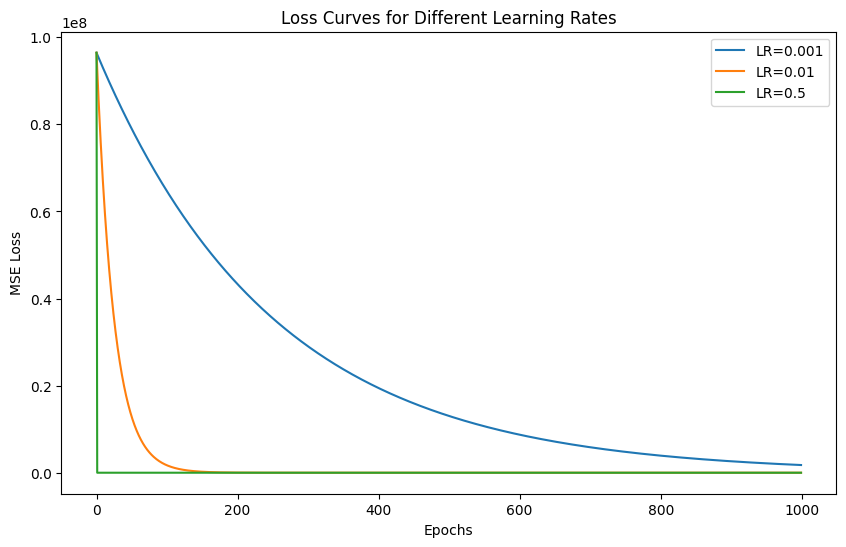

In [13]:
# Run for different learning rates
learning_rates = [0.001, 0.01, 0.5]
epochs = 1000

plt.figure(figsize=(10, 6))
for lr in learning_rates:
    theta, losses = gradient_descent(X_design, y, lr, epochs)
    print(f"LR={lr}: theta0={theta[0]:.2f}, theta1={theta[1]:.2f}, final_loss={losses[-1]:.2f}")
    plt.plot(losses, label=f"LR={lr}")

plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.title("Loss Curves for Different Learning Rates")
plt.legend()
plt.show()


In [14]:
# Final model with best LR (0.01)
theta_best, _ = gradient_descent(X_design, y, 0.01, epochs)
y_pred = X_design @ theta_best
rmse = np.sqrt(mse_loss(y, y_pred))
print(f"\nFinal RMSE: {rmse:.2f}")


Final RMSE: 57.52


## Multi-Output Linear Regression

In [16]:
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.datasets import load_linnerud
import pandas as pd

In [17]:
# Load data
linnerud = load_linnerud()
X, y = linnerud.data, linnerud.target
feature_names = linnerud.feature_names
target_names = linnerud.target_names

In [18]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [19]:
# Multi-output model
model = MultiOutputRegressor(LinearRegression())
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [20]:
# Evaluate each output
results = []
for i, name in enumerate(target_names):
    r2 = r2_score(y_test[:, i], y_pred[:, i])
    mae = mean_absolute_error(y_test[:, i], y_pred[:, i])
    results.append([name, round(r2, 4), round(mae, 2)])

In [21]:
# Display results
df_results = pd.DataFrame(results, columns=["Target", "R² Score", "MAE"])
print(df_results.to_string(index=False))

Target  R² Score   MAE
Weight   -1.2433 20.60
 Waist   -0.0755  1.62
 Pulse   -2.7325  8.08
